# [LAB 06] 데이터 시각화 - 6. Violin Plot

## #01. 준비작업 

### 1. 라이브러리 참조 

In [27]:
from jussam import load_data
from helpers import * 
import seaborn as sb

### 2. 데이터 가져오기 

In [28]:
origin = load_data("stat_comp_grade")
origin.head()

📚 통계학 전공(STAT) 학생과 전산학 전공(COMP) 학생의 통계학 과목에 대한 중간고사 성적과 기말시험 성적 (출처: 방송통신대학교 통계학개론 수업내용에서 발췌)


,전공,중간고사,기말고사
0,STAT,34,86
1,STAT,50,77
2,STAT,75,74
3,COMP,76,96
4,COMP,61,78


## #02. ViolinPlot 시각화 

### 1. 자동 인식 패턴 

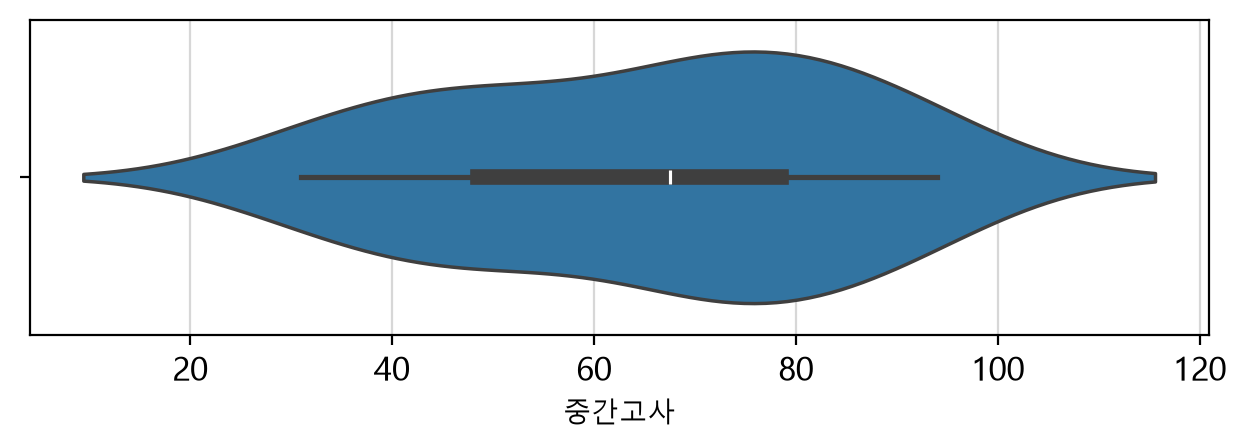

In [29]:
# 그래프 초기화 
fig, ax = my_plot.init(width=640,height=240)

# 그래프 그리기 
sb.violinplot(data=origin['중간고사'], orient="h") 
ax.set_xlabel("중간고사", fontsize=10)

# 출력 
my_plot.show()

### 2. 자동 인식 패턴에 DataFrame 지정을 위한 데이터 전처리 

In [30]:
df = origin[['중간고사', '기말고사']]
df.head()

,중간고사,기말고사
0,34,86
1,50,77
2,75,74
3,76,96
4,61,78


### 3. 자동 인식 패턴에 DataFrame 지정 

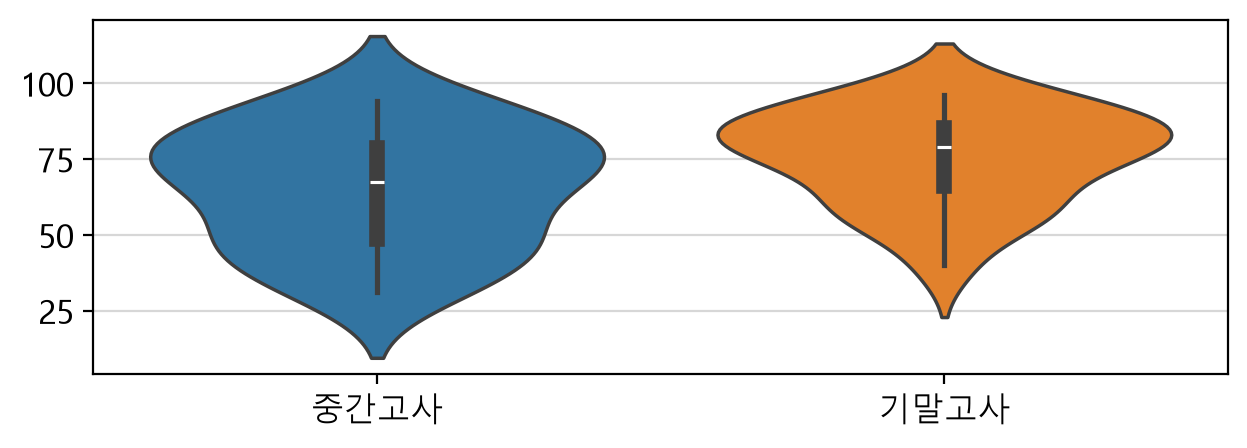

In [31]:
# 그래프 초기화 
fig, ax = my_plot.init(width=640,height=240)

# 그래프 그리기 
sb.violinplot(data=origin, orient="v") 

# 출력 
my_plot.show()

### 4. 개별 데이터 직접 지정 패턴

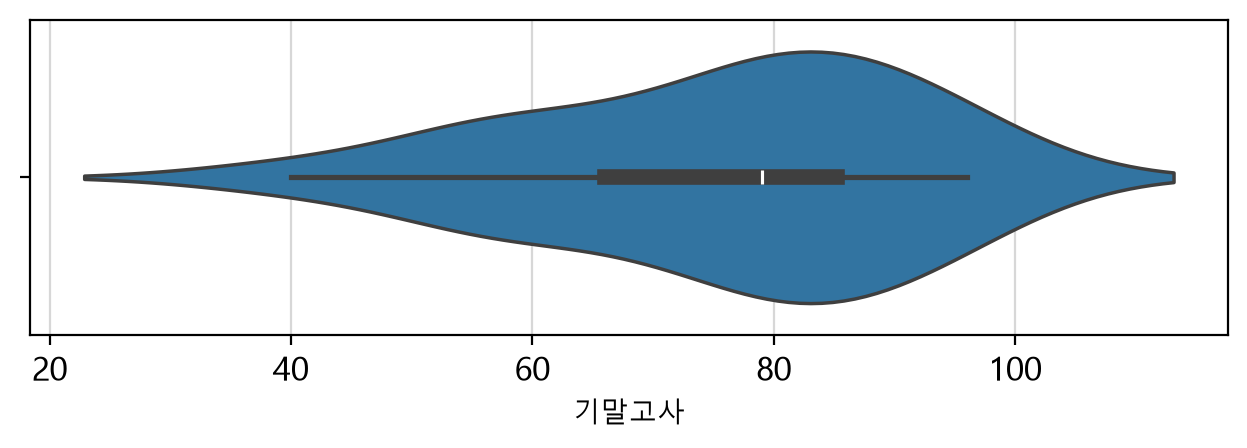

In [32]:
# 그래프 초기화 
fig, ax = my_plot.init(width=640,height=240)

# 그래프 그리기
# # -> 데이터가 x축으로 전개되므로 가로 방향 그래프가 된다.  
sb.violinplot(x=df['기말고사']) 
ax.set_xlabel("기말고사", fontsize=10)

# 출력 
my_plot.show()

### 5. 데이터 프레임 + 컬럼명 패턴 

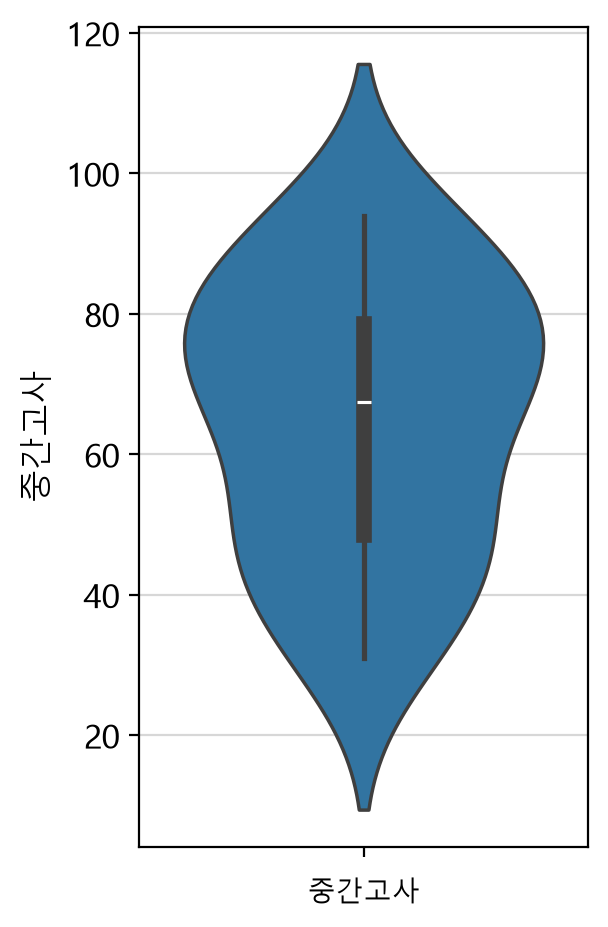

In [33]:
# 그래프 초기화 
fig, ax = my_plot.init(width=320,height=480)

# 그래프 그리기 
sb.violinplot(data=origin, y="중간고사") 
ax.set_xlabel("중간고사", fontsize=10)

# 출력 
my_plot.show()

### 범주(hue) 지정 

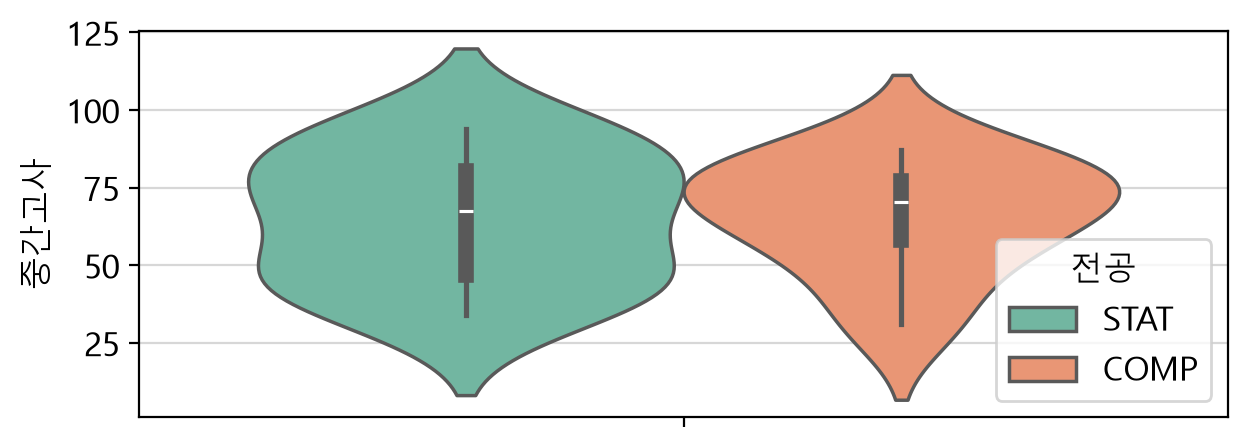

In [34]:
# 그래프 초기화 
fig, ax = my_plot.init(width=640,height=240)

# 그래프 그리기 
sb.violinplot(data=origin, y='중간고사', hue='전공', palette='Set2') 

# 출력 
my_plot.show()

## #05. 모듈화 기능 확인 

### 1. 상자그림 모듈화와 사용방법이 동일하므로 여기서는 대표 사례 하나만 확인 

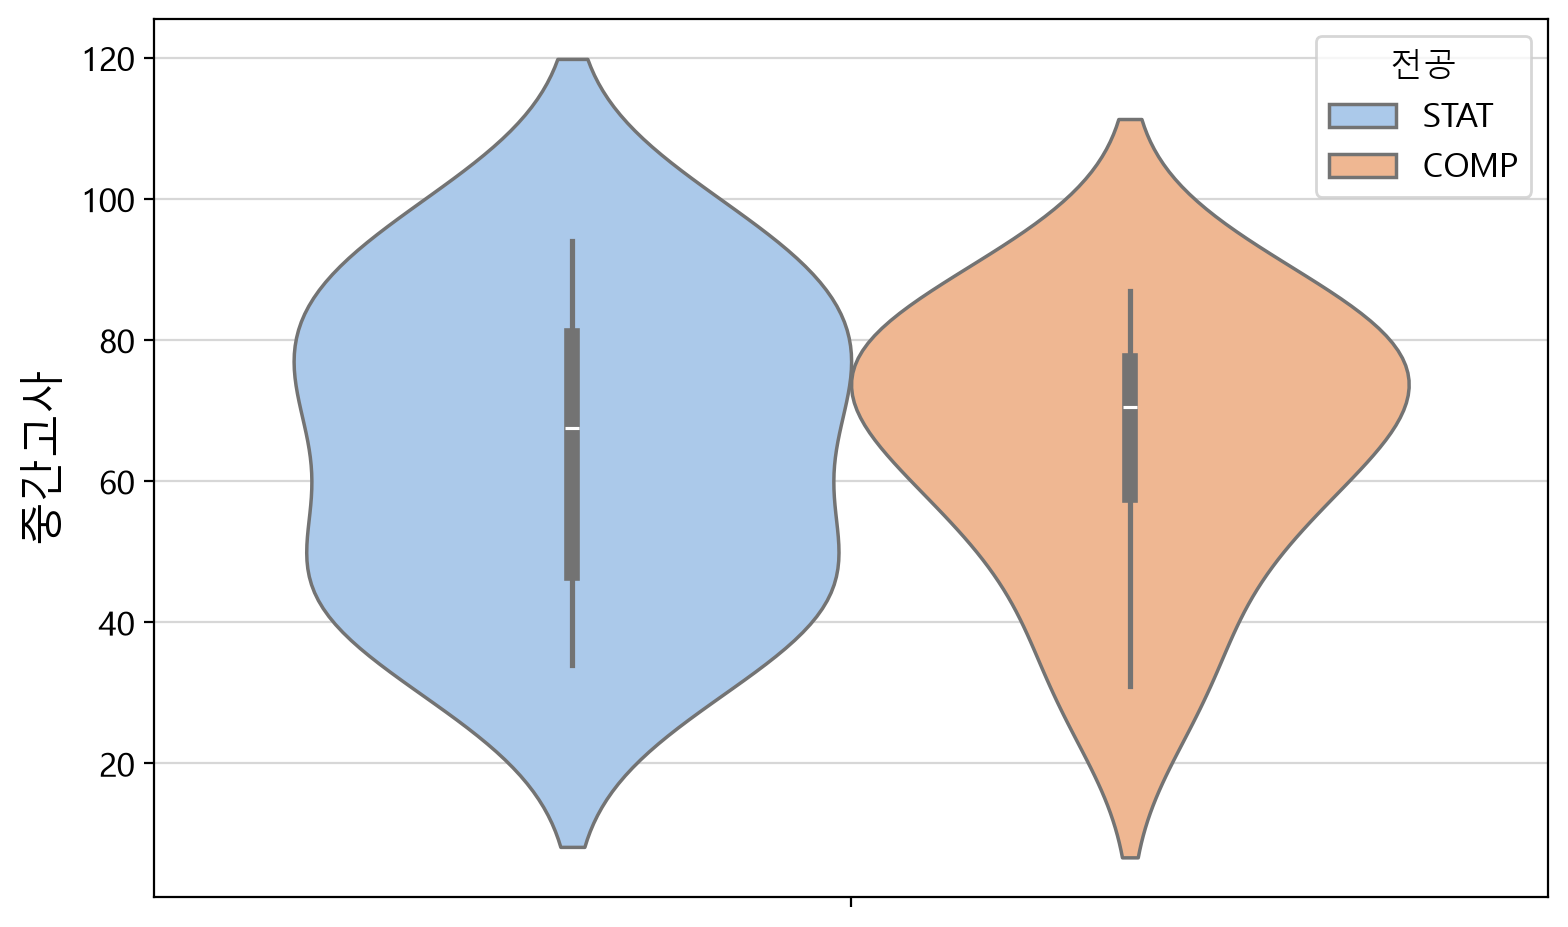

In [35]:
my_plot.violinPlot(data=origin, y='중간고사', hue='전공', ylabel="중간고사",
                   width=800, height=480, palette='pastel')

## #01. 연습문제 

In [36]:
from jussam import load_data
from helpers import *
import seaborn as sb
from pandas import concat

In [37]:
origin = load_data('cookie_cats')
origin

📚 어느 모바일 게임의 버전에 따른 유저별 총 플레이 시간을 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,version,sum_gamerounds
userid,,
116,A,3
337,A,38
377,B,165
483,B,1
488,B,179
...,...,...
9999441,B,97
9999479,B,30
9999710,A,28


In [38]:
df_a = origin[origin['version'] =='A']
df_a

,version,sum_gamerounds
userid,,
116,A,3
337,A,38
1066,A,0
2101,A,0
2179,A,39
...,...,...
9998576,A,14
9998623,A,7
9999178,A,21


In [39]:
desc_df = my_qtcheck.numerical_summary(df_a)
desc_df

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
sum_gamerounds,44700.000,52.456,256.716,0.000,5.000,17.000,50.000,49854.000,2.086,large_diff,45.000,117.500,-62.500,5207,0.116,0,0.000,5207,0.116,163.710,right tail,31688.381,leptokurtic,log1p


In [40]:
df_a_qt = df_a[(df_a['sum_gamerounds'] >= desc_df['lower_bound']['sum_gamerounds']) & (df_a['sum_gamerounds'] <= desc_df['upper_bound']['sum_gamerounds'])]
df_a_qt

,version,sum_gamerounds
userid,,
116,A,3
337,A,38
1066,A,0
2101,A,0
2179,A,39
...,...,...
9998576,A,14
9998623,A,7
9999178,A,21


In [41]:
df_b = origin[origin['version'] =='B']
df_b

,version,sum_gamerounds
userid,,
377,B,165
483,B,1
488,B,179
540,B,187
1444,B,2
...,...,...
9998733,B,10
9999441,B,97
9999479,B,30


In [42]:
desc_df = my_qtcheck.numerical_summary(df_b)
desc_df

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
sum_gamerounds,45489.000,51.299,103.294,0.000,5.000,16.000,52.000,2640.000,2.206,large_diff,47.000,122.500,-65.500,5018,0.110,0,0.000,5018,0.110,5.967,right tail,63.106,leptokurtic,log1p


In [43]:
df_b_qt = df_b[(df_b['sum_gamerounds'] >= desc_df['lower_bound']['sum_gamerounds']) & (df_b['sum_gamerounds'] <= desc_df['upper_bound']['sum_gamerounds'])]
df_b_qt

,version,sum_gamerounds
userid,,
483,B,1
1444,B,2
1574,B,108
1842,B,3
2132,B,30
...,...,...
9998733,B,10
9999441,B,97
9999479,B,30


In [44]:
df_qtcheck = concat([df_a_qt, df_b_qt], ignore_index=True)
df_qtcheck

,version,sum_gamerounds
0,A,3
1,A,38
2,A,0
3,A,0
4,A,39
...,...,...
79959,B,10
79960,B,97
79961,B,30
79962,B,51


In [45]:
df_qtcheck = concat([df_a_qt, df_b_qt], ignore_index=False)
df_qtcheck

,version,sum_gamerounds
userid,,
116,A,3
337,A,38
1066,A,0
2101,A,0
2179,A,39
...,...,...
9998733,B,10
9999441,B,97
9999479,B,30


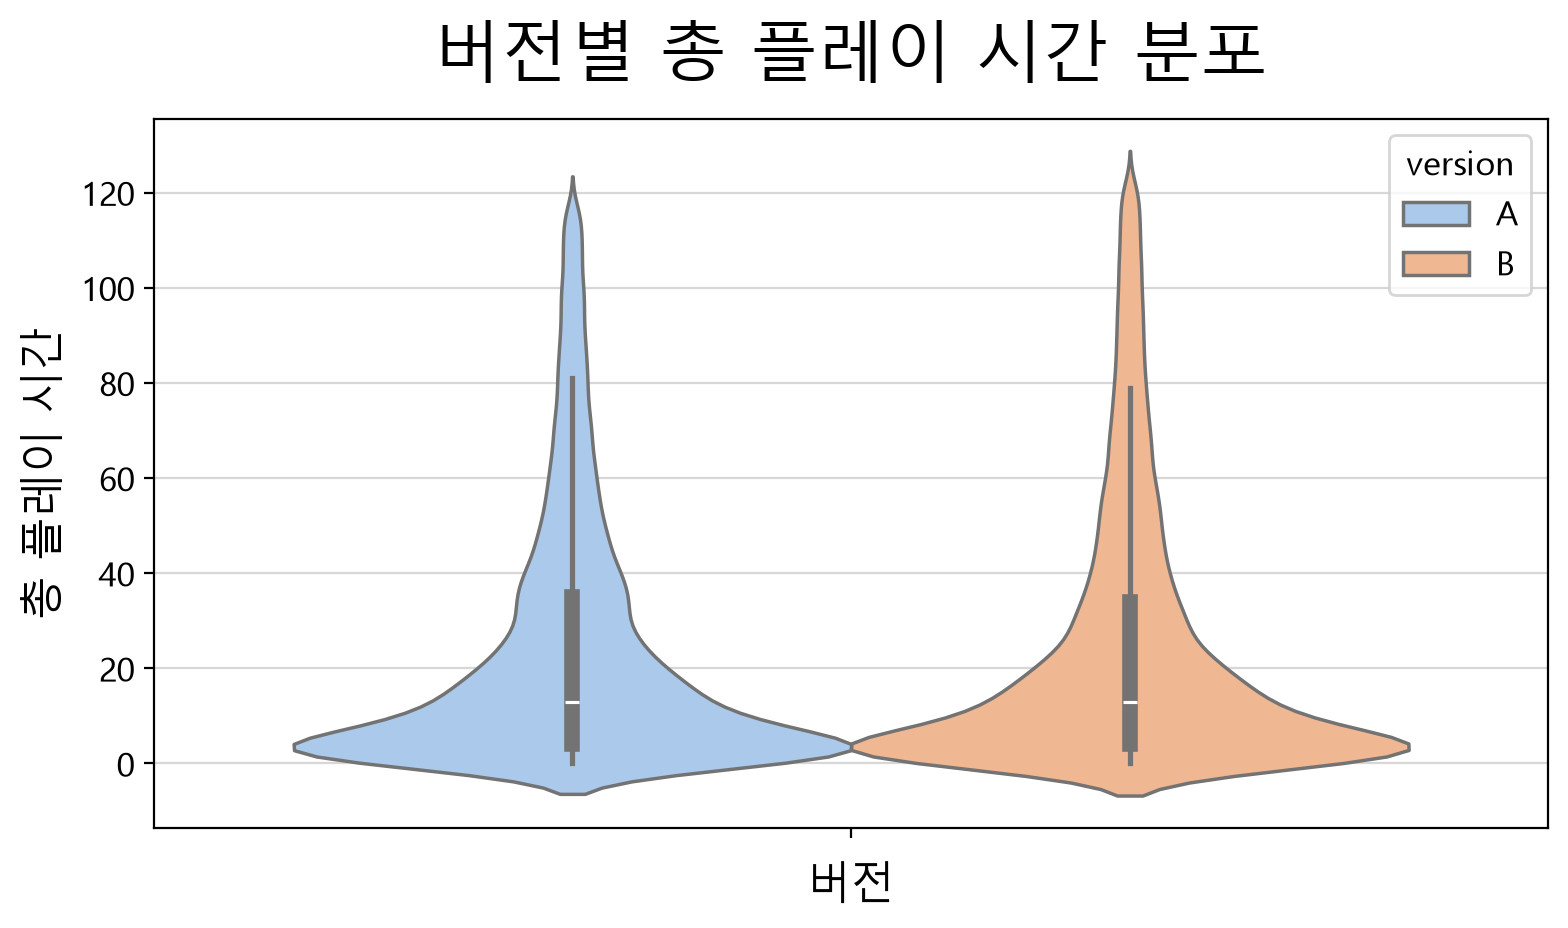

In [46]:
my_plot.violinPlot(data=df_qtcheck, y='sum_gamerounds', hue='version', 
                   width=800, height=480, palette='pastel',
                   title="버전별 총 플레이 시간 분포", xlabel="버전", ylabel="총 플레이 시간")

In [47]:
import helpers.my_plot as my_plot
print(dir(my_plot))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'boxplot', 'init', 'kdeplot', 'lineplot', 'np', 'platform', 'plt', 'sb', 'show', 'violinPlot']


In [48]:
import matplotlib.pyplot as plt
print(plt.rcParams['font.family'])

['Malgun Gothic']
